### 데이터 전처리

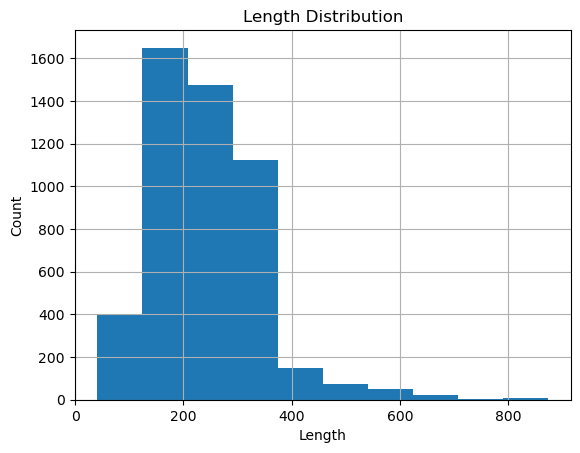

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

train_combined_path ="normal_conversations/train_combined.csv"
train_combined = pd.read_csv(train_combined_path)

train_combined['conversation'].str.len().hist()
plt.title('Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

In [4]:
max(train_combined['conversation'].str.len())

874

In [5]:
# idx 컬럼 삭제
train_combined.drop(['idx'], axis=1,inplace=True)

# 정규표현식
import re

def standard_preprocess(text):
    if not isinstance(text, str):
        return ""
    
    # 1. 줄바꿈, 탭 등 공백 문자 정규화
    text = re.sub(r'\s+', ' ', text)
    
    # 2. URL 및 이메일 제거 (선택 사항)
    text = re.sub(r'http\S+|www\S+|mailto:\S+', '', text)
    
    # 3. 특수문자 정제 (한글, 숫자, 기본 문장부호만 남기기)
    # KLUE 모델은 문장부호를 이해하므로 .?!,는 남겨두는 것이 좋습니다.
    text = re.sub(r'[^가-힣0-9a-zA-Zㄱ-ㅎㅏ-ㅣ\s.?!,]', '', text)
    
    return text.strip()

In [8]:
train_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4950 entries, 0 to 4949
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   class         4950 non-null   object
 1   label         4950 non-null   int64 
 2   conversation  4950 non-null   object
dtypes: int64(1), object(2)
memory usage: 116.1+ KB
